In [1]:
import os
import sys
newPath = os.path.dirname(os.path.abspath(""))
if newPath not in sys.path:
    sys.path.append(newPath)
from BayesForge import bf

m = bf(platform='cpu')


/home/sebastian_sosa/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


bf v 0.0.51 package loaded
jax.local_device_count 24


# Plots interactives

## 1d hist

In [3]:
m.dist.normal(0,1, name = 'a', shape=(100,), sample = True).hist()

## 2d hist

In [4]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).hist()

## 3d hist

In [5]:
m.dist.normal(0,1, name = 'a', shape=(100,4, 5), sample = True).hist()

## Correlation matrix

In [6]:
m.dist.lkj_cholesky(4, 2, name = 'a', sample = True)

SampledData([[ 1.        ,  0.        ,  0.        ,  0.        ],
       [-0.03956199,  0.99921712,  0.        ,  0.        ],
       [ 0.03434641, -0.39666028,  0.91732271,  0.        ],
       [-0.63391387,  0.27601928, -0.44537398,  0.56886604]],      dtype=float64)

In [7]:
m.dist.lkj_cholesky(4, 2, name = 'a', sample = True).corr_heatmap()

## Boxplot

In [8]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).boxplot()

## Violinplot

In [9]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).violinplot()

## Pairplot

In [10]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).pairplot()


## Time series

In [11]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).timeseries()


## Scatter3d

In [12]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).scatter3d()


## Traceplot

In [13]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).traceplot()


## Autocorr

In [14]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).autocorr()

## Surface 3d

In [15]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).surface_3d(title="3D Surface Plot of a Sinc Function")

## Ridgeline

In [16]:
import jax.numpy as jnp
m.dist.normal(m.dist.categorical(probs=jnp.array([0.1, 0.8,0.1,0.]),shape=(1000,4),sample=True),5,sample=True).ridgeline(title="Ridgeline Plot of Four Categories")

TypeError: 'module' object is not callable

## Ppc_plot

In [17]:
m.dist.normal(0,1,shape=(100,4),sample=True).ppc_plot(m.dist.normal(0,1,shape=(1,4),sample=True))

## Density

In [18]:
m.dist.normal(0,1,shape=(100,4),sample=True).density()

# Non interactive plots

In [21]:
import os
import sys
newPath = os.path.dirname(os.path.abspath(""))
if newPath not in sys.path:
    sys.path.append(newPath)
from BayesForge import bf

m = bf(platform='cpu')


jax.local_device_count 24


## 1d hist

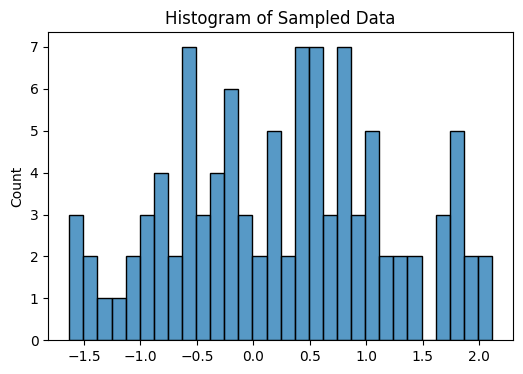

In [22]:

m.dist.normal(0,1, name = 'a', shape=(100,), sample = True).hist(interactive=False)


## 2d hist

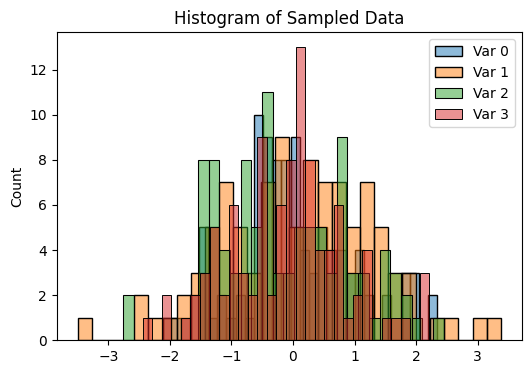

In [23]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).hist(interactive=False)

## 3d hist

In [24]:
m.dist.normal(0,1, name = 'a', shape=(100,4, 5), sample = True).hist(interactive = False)

ValueError: Density plot is only supported for 1D or 2D data. Your data has 3 dimensions.

## Correlation matrix

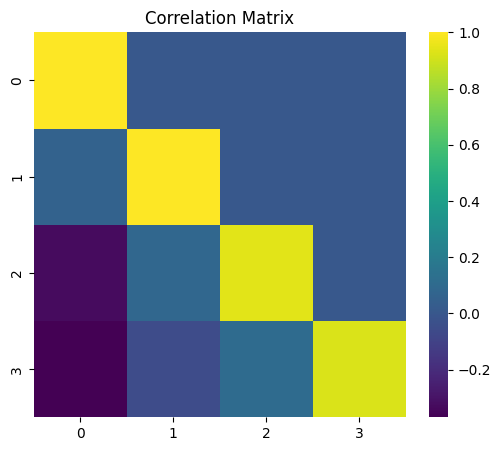

In [25]:
m.dist.lkj_cholesky(4, 2, name = 'a', sample = True).corr_heatmap(interactive = False)

## Boxplot

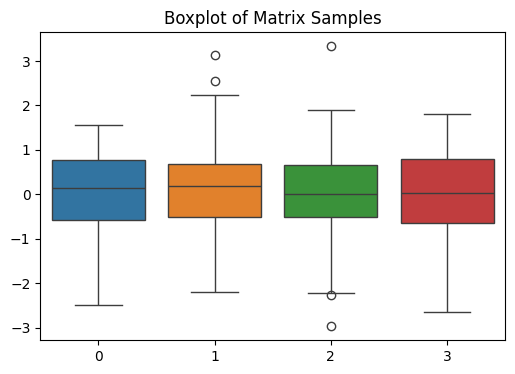

In [26]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).boxplot(interactive = False)

## Violinplot

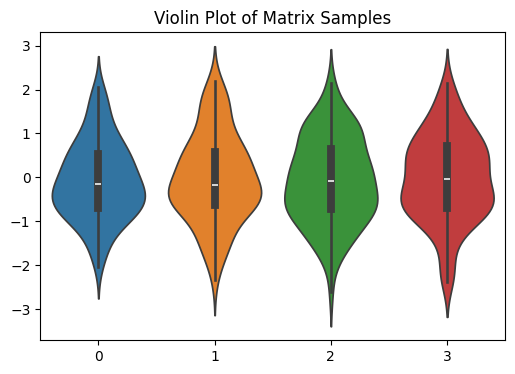

In [27]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).violinplot(interactive = False)

## Pairplot

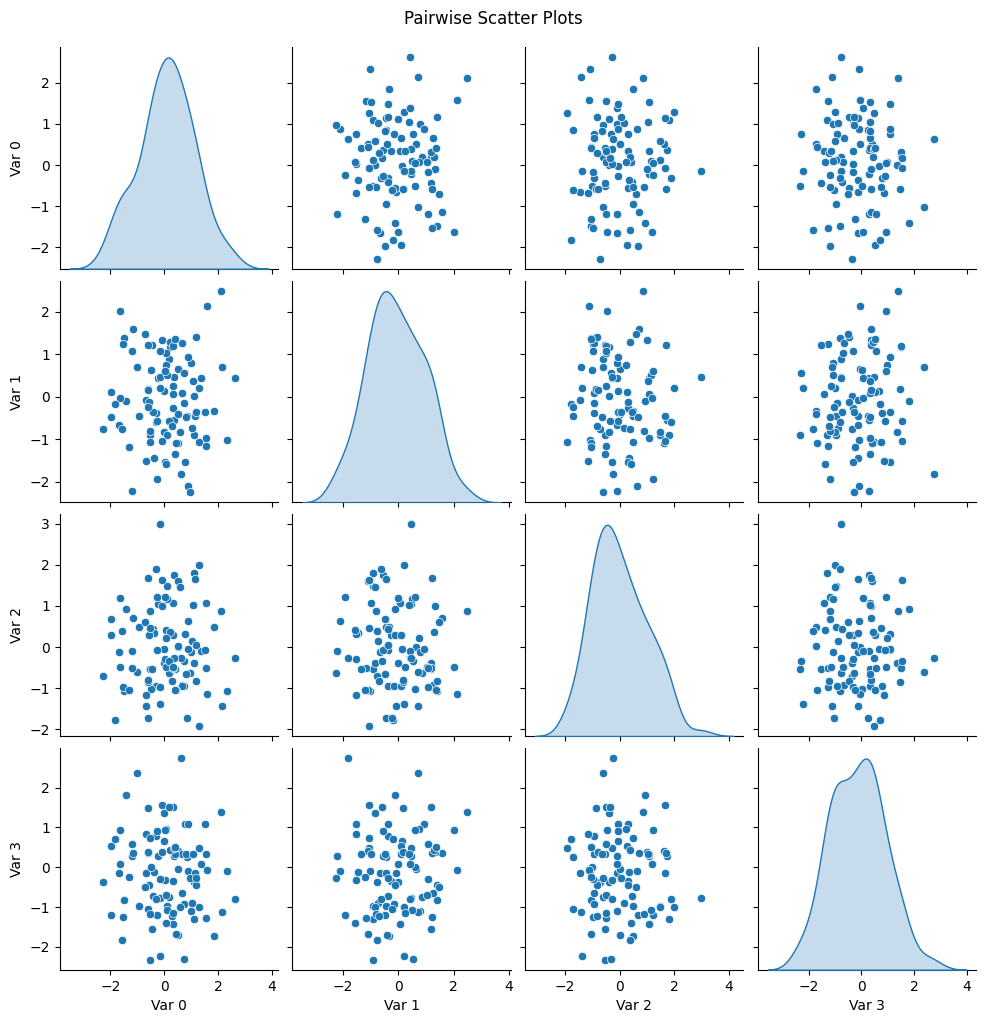

In [28]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).pairplot(interactive = False)

## Time series

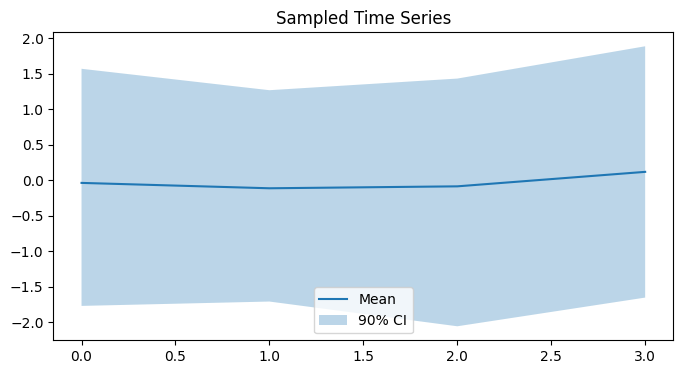

In [29]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).timeseries(interactive = False)

## Scatter3d

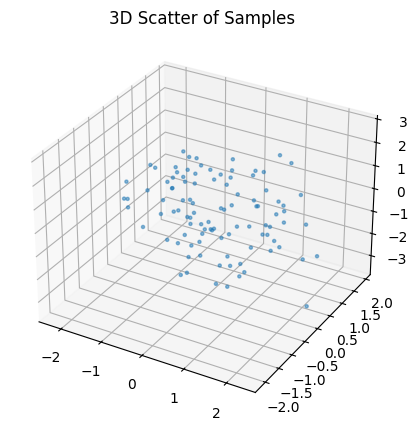

In [30]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).scatter3d(interactive = False)

## Traceplot

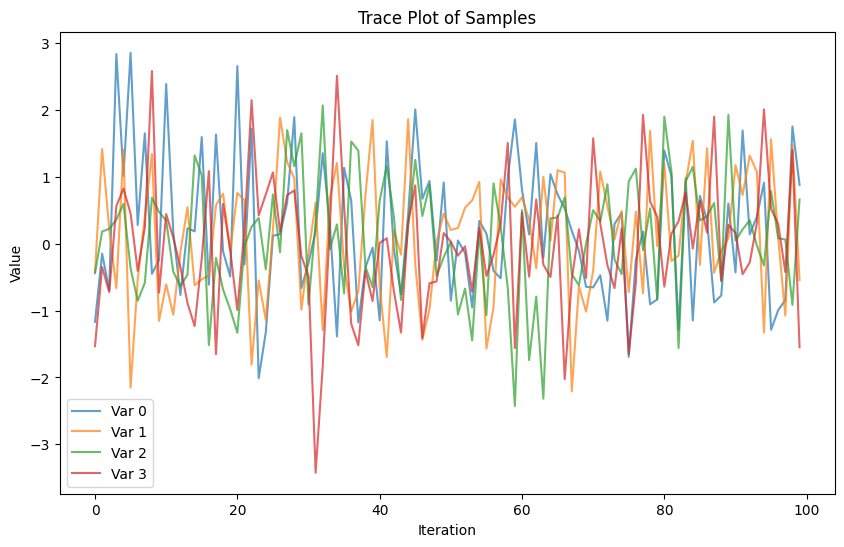

In [31]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).traceplot(interactive = False)

## Autocorr

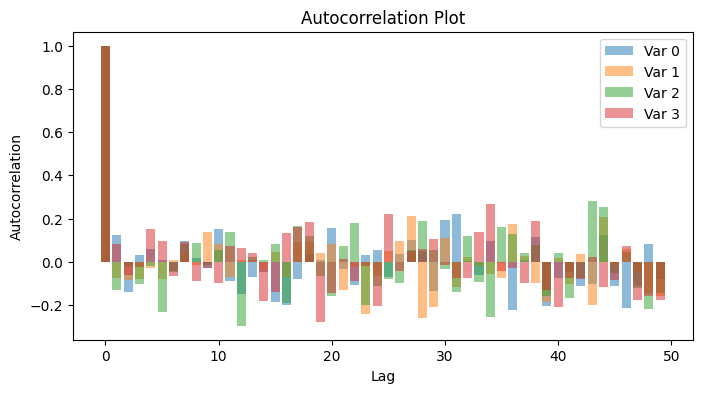

In [32]:
m.dist.normal(0,1, name = 'a', shape=(100,4), sample = True).autocorr(interactive = False)

## Ridgeline

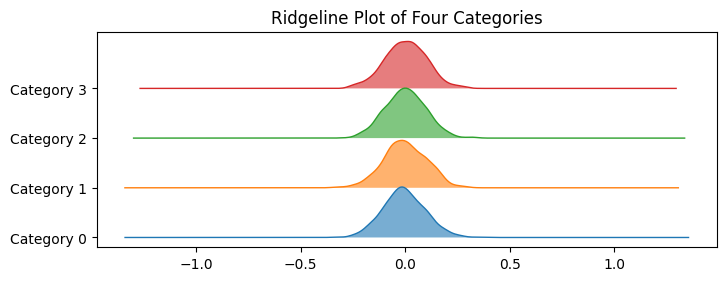

In [33]:
import jax.numpy as jnp
m.dist.normal(0,0.1, shape=(1000,4), sample=True).ridgeline(title="Ridgeline Plot of Four Categories", interactive = False, offset=4)

# From poteriors

In [37]:
import os
import sys
newPath = os.path.dirname(os.path.abspath(""))
if newPath not in sys.path:
    sys.path.append(newPath)
from BayesForge import bf

m = bf(platform='cpu')
data_path = os.path.dirname(os.path.abspath("")) + "/BI/resources/data/"

jax.local_device_count 24


In [38]:
import time as tm
# setup platform------------------------------------------------
m = bf(platform='cpu')

# import data ------------------------------------------------
data_path = m.load.howell1(only_path=True)
m.data(data_path, sep=";")
m.df = m.df[m.df.age > 18]  # Subset data to adults
m.scale(["weight"])  # Normalize


# define model ------------------------------------------------
def model(weight, height):    
    a = m.dist.normal( 178, 20, name = 'a')
    b = m.dist.log_normal( 0, 1, name = 'b')   
    s = m.dist.uniform( 0, 50, name = 's')
    m.dist.normal(a + b * weight , s, obs=height)

# Run sampler ------------------------------------------------
m.fit(model, num_samples=500, num_chains=4) 
m.summary()

jax.local_device_count 24


Compiling.. :   0%|          | 0/1500 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1500 [00:02<?, ?it/s]





Running chain 0:  85%|████████▌ | 1275/1500 [00:03<00:00, 6605.89it/s]

Running chain 3: 100%|██████████| 1500/1500 [00:03<00:00, 489.80it/s]


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,154.66,0.28,154.22,155.10,0.01,0.0,1906.83,1494.03,1.0
b,5.81,0.28,5.39,6.29,0.01,0.0,2278.57,1585.72,1.0
s,5.14,0.20,4.83,5.44,0.00,0.0,2174.03,1519.20,1.0


In [39]:
m.diag.density()

In [40]:
m.diag.pair()

In [41]:
m.diag.plot_trace()

In [42]:
m.diag.autocor()

In [43]:
m.diag.forest()

In [44]:
m.diag.forest()